# Theory Discussion: Why CFR Works

Counterfactual Regret Minimization (CFR) is an algorithm for computing approximate Nash equilibria in imperfect-information games. It operates by minimizing regret locally at each information set and guarantees convergence (in two-player zero-sum games) through averaging.


## Regret Minimization

Consider a repeated decision problem with action set $A$. At each iteration $t$, a strategy $\sigma^t$ selects actions with some probability distribution.

The regret for action $a$ after $T$ iterations is:

$$
R_T(a) = \sum_{t=1}^T \left( u(a) - u(\sigma^t) \right)
$$

where:
- $u(a)$ is the utility of always playing action $a$
- $u(\sigma^t)$ is the utility of the strategy used at iteration $t$

Regret measures how much better an action would have performed compared to the strategy actually used.

Regret matching converts regrets into a strategy:

$$
\sigma(a) =
\begin{cases}
\frac{\max(R_T(a), 0)}{\sum_{a'} \max(R_T(a'), 0)} & \text{if denominator > 0} \\
\frac{1}{|A|} & \text{otherwise}
\end{cases}
$$

This means that actions with positive regret are played more often.

## From Regret Matching to CFR

In extensive-form games like poker, players do not observe the full game state. Instead, they act based on **information sets**.

An information set $I$ represents all game states that are indistinguishable to the player. CFR applies regret minimization independently at each information set.

The total regret becomes:

$$
R_T(I, a)
$$

which represents regret for taking action $a$ at information set $I$.


## Counterfactual Regret

In imperfect-information games, many information sets are reached only rarely. CFR addresses this using **counterfactual regret**.

Counterfactual regret asks:

> If we had reached information set $I$, how much better would action $a$ have been?

Formally, regret updates are weighted by reach probabilities:

$$
R(I, a) \leftarrow R(I, a) + \pi^{-i}(I) \left( u(I, a) - u(I) \right)
$$

where:
- $\pi^{-i}(I)$ is the probability that the opponent and chance reach $I$
- $u(I, a)$ is the utility of taking action $a$
- $u(I)$ is the expected utility under the current strategy

This allows CFR to learn meaningful updates even for rarely visited parts of the game tree.


## Average Strategy and Convergence

CFR does not guarantee that the strategy at each iteration converges. Instead, convergence applies to the **average strategy**:

$$
\bar{\sigma}(a) = \frac{1}{T} \sum_{t=1}^T \sigma^t(a)
$$

The key theoretical result is:

- If average regret goes to zero, the average strategy approaches a Nash equilibrium.

Cumulative regret grows sublinearly:

$$
R_T = O(\sqrt{T})
$$

Therefore, average regret decreases as:

$$
\frac{R_T}{T} = O\left(\frac{1}{\sqrt{T}}\right)
$$

On a log-log plot, this appears approximately as a straight line with slope $-1/2$.


## Why CFR Works

CFR decomposes a large game into many local regret minimization problems. Each information set independently updates its strategy using regret matching.

Key properties:

- Local regret minimization ensures no action is systematically better in hindsight
- Counterfactual weighting ensures meaningful updates across the game tree
- Averaging stabilizes oscillations in strategies

Together, these lead to convergence toward equilibrium strategies in two-player zero-sum games.


## CFR vs Reinforcement Learning

CFR differs from standard reinforcement learning methods such as Q-learning:

- CFR minimizes regret rather than maximizing reward
- CFR explicitly handles imperfect information via information sets
- CFR targets Nash equilibrium rather than best response to a fixed environment

In competitive games like poker, equilibrium strategies are essential because opponents are strategic and adaptive.

## Toy Example: Regret Matching in Rock-Paper-Scissors Self-Play

To make the regret-minimization idea concrete, we apply regret matching to rock-paper-scissors. Unlike the earlier CFR implementation, this is not an imperfect-information game tree. It is a simpler normal-form zero-sum game, but it uses the same regret-matching mechanism that CFR applies at each information set.

Rock-paper-scissors has a known Nash equilibrium:

$$
\sigma^* = \left(\frac{1}{3}, \frac{1}{3}, \frac{1}{3}\right)
$$

Each player starts with small random regret values, so their initial strategies are not exactly uniform. Both players then update their strategies through regret matching. The expected result is that the **average strategies** converge toward the uniform equilibrium.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

NUM_ITERATIONS = 500_000
ACTIONS = ["Rock", "Paper", "Scissors"]

# Payoff matrix for Player 0
# rows = P0 action, cols = P1 action
PAYOFF = np.array([
    [0, -1,  1],   # Rock
    [1,  0, -1],   # Paper
    [-1, 1,  0],   # Scissors
])


def get_strategy(regret_sum):
    positive_regret = np.maximum(regret_sum, 0)

    if positive_regret.sum() > 0:
        return positive_regret / positive_regret.sum()

    return np.ones(3) / 3


# small random initialization so neither player starts exactly uniform
p0_regret_sum = np.random.uniform(-0.1, 0.1, 3)
p1_regret_sum = np.random.uniform(-0.1, 0.1, 3)

p0_strategy_sum = np.zeros(3)
p1_strategy_sum = np.zeros(3)

p0_strategies = []
p1_strategies = []
p0_avg_strategies = []
p1_avg_strategies = []
game_values = []
p0_regrets = []
p1_regrets = []

for t in range(1, NUM_ITERATIONS + 1):
    p0_strategy = get_strategy(p0_regret_sum)
    p1_strategy = get_strategy(p1_regret_sum)

    # Expected value of each pure action against opponent strategy
    p0_action_values = PAYOFF @ p1_strategy
    p1_action_values = (-PAYOFF.T) @ p0_strategy

    # Expected value of current mixed strategy
    p0_value = p0_strategy @ p0_action_values
    p1_value = p1_strategy @ p1_action_values

    # Regret updates
    p0_regret_sum += p0_action_values - p0_value
    p1_regret_sum += p1_action_values - p1_value

    # Average strategy tracking
    p0_strategy_sum += p0_strategy
    p1_strategy_sum += p1_strategy

    p0_avg = p0_strategy_sum / p0_strategy_sum.sum()
    p1_avg = p1_strategy_sum / p1_strategy_sum.sum()

    p0_strategies.append(p0_strategy.copy())
    p1_strategies.append(p1_strategy.copy())
    p0_avg_strategies.append(p0_avg.copy())
    p1_avg_strategies.append(p1_avg.copy())
    game_values.append(p0_value)

    p0_regrets.append(np.sum(np.maximum(p0_regret_sum, 0)) / t)
    p1_regrets.append(np.sum(np.maximum(p1_regret_sum, 0)) / t)

p0_strategies = np.array(p0_strategies)
p1_strategies = np.array(p1_strategies)
p0_avg_strategies = np.array(p0_avg_strategies)
p1_avg_strategies = np.array(p1_avg_strategies)

print("Player 0 average strategy:", p0_avg_strategies[-1])
print("Player 1 average strategy:", p1_avg_strategies[-1])
print("Equilibrium strategy:      ", np.ones(3) / 3)

Player 0 average strategy: [0.3342949  0.33328271 0.33242238]
Player 1 average strategy: [0.33270628 0.33343421 0.33385951]
Equilibrium strategy:       [0.33333333 0.33333333 0.33333333]


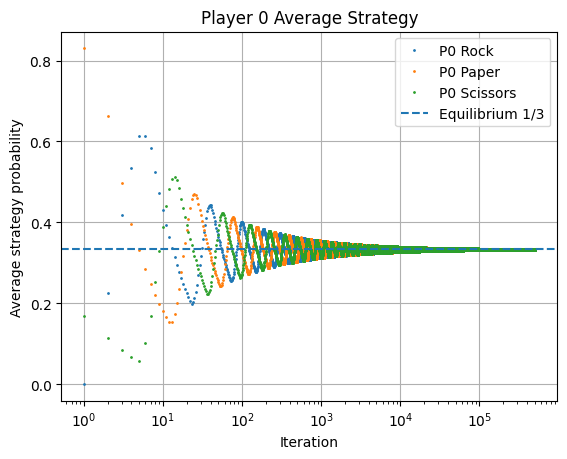

In [5]:

plt.figure()

for i, action in enumerate(ACTIONS):
    plt.plot(p0_avg_strategies[:, i], "o", markersize=1, label=f"P0 {action}")

plt.axhline(1/3, linestyle="--", label="Equilibrium 1/3")
plt.xscale("log")
plt.xlabel("Iteration")
plt.ylabel("Average strategy probability")
plt.title("Player 0 Average Strategy")
plt.grid(True)
plt.legend()
plt.show()

## Average Strategy Convergence

This plot shows Player 0's average strategy over time. In regret minimization, the instantaneous strategy may oscillate, especially in cyclic games like rock-paper-scissors. The important object is the **average strategy**, which should converge toward equilibrium.

We can see the oscillation above. This oscillation results from the other player simultaneously adapting their own strategy through regret updates. As one player shifts probability toward an action, the opponent adjusts in response, which can temporarily make previously strong actions weaker and vice versa. In cyclic games such as rock-paper-scissors, this creates a continual feedback loop in the instantaneous strategies.

However, the average strategy smooths out these oscillations over time. Even though the current strategy may continue moving around the equilibrium, the running average converges toward the Nash equilibrium distribution.

Because rock-paper-scissors is symmetric and zero-sum, the equilibrium probability for each action is $1/3$.

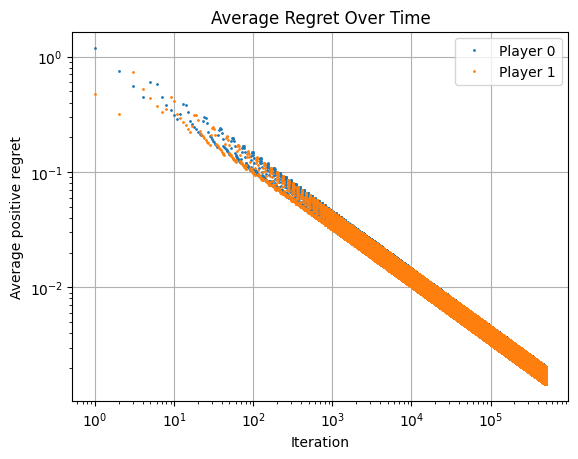

In [6]:

plt.figure()
plt.plot(p0_regrets, "o", markersize=1, label="Player 0")
plt.plot(p1_regrets, "o", markersize=1, label="Player 1")
plt.xscale("log")
plt.yscale("log")

plt.xlabel("Iteration")
plt.ylabel("Average positive regret")
plt.title("Average Regret Over Time")
plt.grid(True)
plt.legend()
plt.show()

## Average Regret

The next plot shows average positive regret for both players:

$$
\frac{1}{T}\sum_a \max(R_T(a), 0)
$$

Cumulative regret does not need to go to zero. The important quantity is **average regret**, which should decrease over time. On a log-log plot, this appears approximately linear because regret minimization gives linear cumulative regret growth, as shown above. It follows the expected slope of -1/2 that we expect from a log-log plot for regret minimization.